INtro to Machine Learning

Mini-Project : Data spliter

In [ ]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split

df = pd.read_csv("Titanic-Dataset.csv")
Y = df["Survived"]
X = df.drop(columns=["Survived"])

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,train_size=0.7)
print("Training half : ")
print(X_train.shape)
print(Y_train.shape)

print("Testing Half : ")
print(X_test.shape)
print(Y_test.shape)

1. Linear Regression

In [ ]:
# linear Regression using sklearn
from sklearn.linear_model import LinearRegression
x = np.random.randint(1,50,size=10).reshape(-1,1)
y = np.random.randint(1,50,size=10)
print(x)
print(y)

model = LinearRegression()
model.fit(x,y)
print("coefficient of determination:",model.score(x,y))
print(f"intercept : {model.intercept_}")
print(f"slope : {model.coef_}")

2. Polynomial Regression

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
X = np.random.randint(1,50,size=10).reshape(-1,1)
Y = np.random.randint(1,50,size=10)

print("X : ",X)
print("Y : ",Y)

transformer = PolynomialFeatures(degree=2,include_bias=False)
transformer.fit(X)
X_ = transformer.transform(X)
print("Transformed X : ",X_)

model = LinearRegression()
model.fit(X,Y)
model.score(X,Y)
print("Intercept : ",model.intercept_)
print("Slope : ",model.coef_)

1. Lasso Regulariztion 

In [ ]:
from sklearn.linear_model import Lasso 
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression 

X,Y = make_regression(n_samples=100,n_features=5,random_state=45)
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=45)

model = Lasso(alpha=0.5)
model.fit(X_train,Y_train)
preds = model.predict(X_test)
mse = mean_squared_error(Y_test,preds)
print("mean squared error : ",mse)
print(model.coef_)

2. Ridge Regularization

In [ ]:
from sklearn.linear_model import Ridge 
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

X,Y = make_regression(n_samples=100,n_features=5,random_state=45)
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=45)

model = Ridge(alpha=0.5)

model.fit(X_train,Y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(Y_test,y_pred)
print("mean squared error : ",mse)
print(model.coef_)

Mini-Project : House Price Prediction

In [ ]:
import pandas as pd 
import numpy as np 
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.model_selection import train_test_split


df = pd.read_csv("housing.csv")
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].mean())
Numerical_cols = df.select_dtypes(include=["int64", "float64"])


Y = Numerical_cols["median_house_value"]
X = Numerical_cols.drop(columns=["median_house_value"])


X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=45)

model = LinearRegression()
model.fit(X_train,Y_train)
print("R2 score linear regression: ",model.score(X_test,Y_test))
  

3. Classification Algorithm

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix

X = np.random.randint(1,50,size=10).reshape(-1,1)
y = np.array([1,0,0,0,1,0,1,0,1,0])

model = LogisticRegression()
model.fit(X,y)
print(model.score(X,y))
preds = model.predict(X)
print(classification_report(preds,y))

2. Support Vector Machine

In [ ]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
from sklearn.datasets import load_breast_cancer 
from sklearn.metrics import classification_report
from sklearn.svm import SVC 

df = load_breast_cancer()
x = df.data
y = df.target 

X_train,X_test,Y_train,Y_test = train_test_split(x,y,random_state=45)

model = SVC(kernel='linear',C=1)
model.fit(X_train,Y_train)

preds = model.predict(X_test)
print("Classification Report : \n",classification_report(preds,Y_test))

3. Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import classification_report,accuracy_score
from sklearn.datasets import load_breast_cancer 
from sklearn.model_selection import train_test_split 

df = load_breast_cancer()
X = df.data
y = df.target 

X_train,X_test,Y_train,Y_test = train_test_split(X,y,random_state=45)

model = DecisionTreeClassifier(
    criterion = 'gini',
    splitter = 'best',
    max_depth = 3,
    min_samples_split=2,
    min_samples_leaf = 1
)


model.fit(X_train,Y_train)
preds = model.predict(X_test)
print("Classification Report : ",classification_report(preds,Y_test))
print("Accuracy Score : ",accuracy_score(preds,Y_test))


4. Random forest classifier 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer 

df = load_breast_cancer() 
X = df.data 
y = df.target

X_train,X_test,Y_train,Y_test = train_test_split(X,y,train_size=0.7,random_state=45)

model = RandomForestClassifier(
    n_estimators = 100,
    criterion = 'gini',
    max_depth = 5,
    min_samples_split=4,
    min_samples_leaf=2
)

model.fit(X_train,Y_train)
preds = model.predict(X_test)
print("classification report : ",classification_report(preds,Y_test))
print("accuracy score :  ",accuracy_score(preds,Y_test))


Mini-Project : Spam Classifier 

In [ ]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report,accuracy_score
import pandas as pd 
import numpy as np 

df = pd.read_csv("spam.csv",encoding="latin-1")
df = df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])
df.info()

df = df.rename(columns={'v1':'target','v2':'text'})
df.info()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer 
from sklearn.preprocessing import LabelEncoder

cv = CountVectorizer()
encoder = LabelEncoder()
X = cv.fit_transform(df['text'].values)
y = encoder.fit_transform(df['target'].values)

X_train,X_test,Y_train,Y_test = train_test_split(X,y,random_state=45)

model = RandomForestClassifier(
    n_estimators = 100,
    criterion = 'gini',
    max_depth = 5,
    min_samples_split=4,
    min_samples_leaf=2
)

model.fit(X_train,Y_train)

preds = model.predict(X_test)

print("Classification report : \n",classification_report(preds,Y_test))
print("accuracy report : ", accuracy_score(preds,Y_test))


Ensemble Learning

Bagging Meta Estimator

In [12]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import cross_val_score
from sklearn import datasets

df = datasets.load_iris()
X,y = df.data,df.target

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    min_samples_leaf = 2,
    min_samples_split=2,
)

bagging = BaggingClassifier(
    estimator=RandomForestClassifier(),
    n_estimators=100,
    max_samples=3
)

for clf , label in zip([rf_model,bagging],["RandomForest","BaggingModel"]):
    scores = cross_val_score(clf,X,y,scoring="accuracy",cv=5)
    print(f"Accuracy : {scores.mean()}, Model : {label}")
    

Accuracy : 0.9533333333333334, Model : RandomForest
Accuracy : 0.3333333333333333, Model : BaggingModel


Voting Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn import datasets

scaler = StandardScaler()
df = datasets.load_iris()
X,y = df.data,df.target

x_train,x_test,y_train,y_test = train_test_split(X,y,random_state=45)

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Training data size : {x_train.shape}\nTesting data size : {x_test.shape}")


classifier_1 = RandomForestClassifier(
    n_estimators=150,
    criterion='entropy',
    max_depth=5,
    min_samples_leaf=2,
)

classifier_2 = LogisticRegression()
classifier_3 = GaussianNB()

combined_classifers = VotingClassifier(
    estimators=[("RF",classifier_1),("LR",classifier_2),("NB",classifier_3)],
    voting="hard",
)


for clf,label in zip([classifier_1,classifier_2,classifier_3,combined_classifers],["RandomForest","LogisticRegression","NaiveBayes","VotingClassifier"]):
    scores = cross_val_score(clf,x_train_scaled,y_train,scoring="accuracy",cv=5)
    print("Accuracy: %f [%s]" % (scores.mean(), label))


Training data size : (112, 4)
Testing data size : (38, 4)
Accuracy: 0.954941 [RandomForest]
Accuracy: 0.963636 [LogisticRegression]
Accuracy: 0.963636 [NaiveBayes]
Accuracy: 0.963636 [VotingClassifier]


Stacking

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import pandas as pd 
import numpy as np 

df = pd.read_csv("d:\\AppstoneLab-AI-intern\\Day-wise\\Day-2\\housing.csv")
df = df.select_dtypes(include=['float64','int64'])
df.info()

df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
y = df['median_house_value']
X = df.drop(columns=["median_house_value"])

print("total datasize : ",X.shape,y.shape)

x_train,x_test,y_train,y_test = train_test_split(X,y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"training Set : {x_train_scaled.shape}")
print(f"Testing Set : {x_test_scaled.shape}")

estimators = [
    ("LinearRegressor",LinearRegression()),
    ("K-NearestRegressor",KNeighborsRegressor()),
    ("RandomForestRegressor",RandomForestRegressor(n_estimators=250))
]

final_estimator = GradientBoostingRegressor(
    n_estimators=250, 
    subsample=0.5, 
    min_samples_leaf=25, 
    max_features=1,
    random_state=42
    )

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator
)

stack.fit(x_train_scaled,y_train)
preds = stack.predict(x_test_scaled)
print(f"Error in prediction : {mean_squared_error(y_test,preds)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
total datasize :  (20640, 8) (20640,)
training Set : (15480, 8)
Testing Set : (5160, 8)
Error in prediction : 2514194032.473195


Mini-Project : Tree vs Forest 

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error 

dc_model = DecisionTreeRegressor(
    criterion = "absolute_error",
    min_samples_leaf=3
)

rf_model = RandomForestRegressor(
    n_estimators = 100,
    criterion = "absolute_error",
    min_samples_leaf=3
)

dc_model.fit(x_train_scaled,y_train)
rf_model.fit(x_train_scaled,y_train)

dc_preds = dc_model.predict(x_test_scaled)
rf_preds = rf_model.predict(x_test_scaled)

print("Error in Decision Tree Regressor : ",mean_absolute_error(y_test,dc_preds))
print("Error in Random Forest Regressor : ",mean_absolute_error(y_test,rf_preds))



Error in Decision Tree Regressor :  39894.72519379845
Error in Random Forest Regressor :  31722.21058624031


MIni-Project : The Boosting Ladder

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

x_train_scaled = x_train_scaled[:2000]
x_test_scaled = x_test_scaled[0:100]
y_train = y_train[:2000]
y_test = y_test[:100]


adaboostmodel = AdaBoostRegressor(
    n_estimators=100,
    random_state=45,
)
Gradientboostmodel = GradientBoostingRegressor(
    learning_rate=0.2,
    n_estimators=100,
)

XGboostmodel = XGBRegressor(
    n_estimators = 100,
    learning_rate = 0.2,
)

adaboostmodel.fit(x_train_scaled,y_train)
Gradientboostmodel.fit(x_train_scaled,y_train)
XGboostmodel.fit(x_train_scaled,y_train)

ada_preds = adaboostmodel.predict(x_test_scaled)
gb_preds = Gradientboostmodel.predict(x_test_scaled)
XG_preds = XGboostmodel.predict(x_test_scaled)

print("Error in AdaBoost : ",mean_absolute_error(y_test,ada_preds))
print("Error in GradientBoost : ",mean_absolute_error(y_test,gb_preds))
print("Error in XGBoost  : ",mean_absolute_error(y_test,XG_preds))



Error in AdaBoost :  72710.80830570412
Error in GradientBoost :  39136.72199908811
Error in XGBoost  :  38628.604375


Mini-Project : Blender 

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC 
from sklearn.linear_model import LogisticRegression 
from sklearn.datasets import load_iris 
from sklearn.metrics import accuracy_score

df = load_iris()
X,y = df.data,df.target 

KNN = KNeighborsClassifier(n_neighbors=4)
RF = RandomForestClassifier(n_estimators=100,criterion='gini')
SVM = SVC(kernel='rbf')

KNN.fit(X,y)
RF.fit(X,y)
SVM.fit(X,y)

knn_preds = KNN.predict(X)
rf_preds = RF.predict(X)
svm_preds = SVM.predict(X)


estimators = [
    ("KNN",KNeighborsClassifier(n_neighbors=4)),
    ("RandomForest",RandomForestClassifier(n_estimators=100,criterion='gini')),
    ("SVM",SVC(kernel='rbf')),
]

final_estimator = LogisticRegression()

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
)

stack.fit(X,y)
preds = stack.predict(X)

print(f"Accuracy for KNN : {accuracy_score(y,knn_preds)}")
print(f"Accuracy for RandomForest : {accuracy_score(y,rf_preds)}")
print(f"Accuracy for SVM : {accuracy_score(y,svm_preds)}")
print(f"Accuracy for Stack : {accuracy_score(y,preds)}")



Accuracy for KNN : 0.96
Accuracy for RandomForest : 1.0
Accuracy for SVM : 0.9733333333333334
Accuracy for Stack : 0.98


2. Clustering 

1. Kmeans Clustering

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster  import KMeans
import matplotlib.pyplot as plt 

X,y = make_blobs(n_samples =100,centers=2,random_state=45)
model = KMeans(n_clusters=2)
model.fit(X)
y_preds = model.predict(X)

centroids = model.cluster_centers_
labels = model.labels_
inertia = model.inertia_ 

plt.scatter(X[:, 0], X[:, 1], c=y_preds, s=50, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', label='Centroids')
plt.title('K-Means Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


Hierarchical Clustering

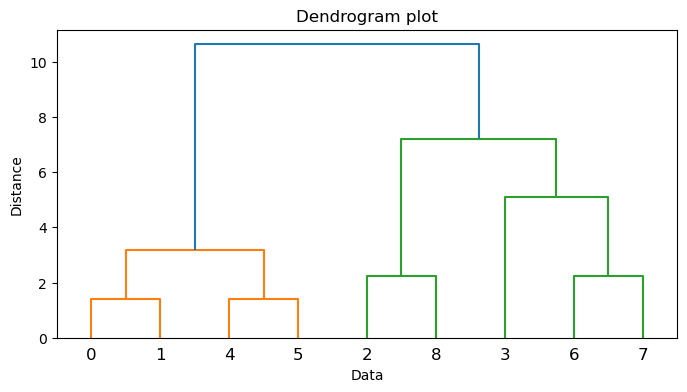

[1 1 2 2 1 1 2 2 2]


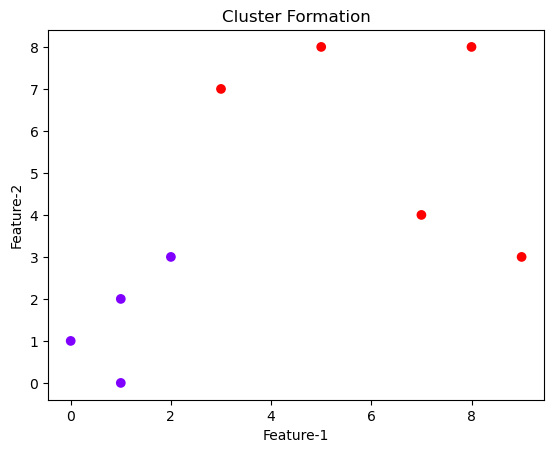

In [56]:
#agglomerative Clustering 
import numpy as np 
from scipy.cluster.hierarchy import linkage,dendrogram,fcluster 
import matplotlib.pyplot as plt 

data = np.array([[1, 2], [2, 3], [5, 8], [8, 8], [1, 0], [0, 1],[7, 4],[9, 3],[3, 7]])

Z = linkage(data,method='complete')

plt.figure(figsize=(8,4))
dendrogram(Z,p=30)
plt.title(label="Dendrogram plot")
plt.xlabel("Data")
plt.ylabel("Distance")
plt.show()

labels = fcluster(Z,t=2,criterion='maxclust')
print(labels)

plt.scatter(data[:,0],data[:,1],c=labels,cmap='rainbow')
plt.title("Cluster Formation")
plt.xlabel("Feature-1")
plt.ylabel("Feature-2")
plt.show()
